In [39]:
!pip install pycaret
!pip install catboost

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
import numpy as np

from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [41]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [42]:
train_data.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [43]:
test_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


- Since test data has no column name `casual`, `registered` we will drop it from the train data.
- test data has no count (output) column. So we will split our train data for traning evaluating model.

In [44]:
train_data.drop(columns=['registered', 'casual'], inplace=True)
train_data.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,1


# Feature Engineering

## 1. Missing Value

In [45]:
train_data.isnull().sum(), test_data.isnull().sum()

(datetime      0
 season        0
 holiday       0
 workingday    0
 weather       0
 temp          0
 atemp         0
 humidity      0
 windspeed     0
 count         0
 dtype: int64,
 datetime      0
 season        0
 holiday       0
 workingday    0
 weather       0
 temp          0
 atemp         0
 humidity      0
 windspeed     0
 dtype: int64)

- No Missing Values.

## 2.Extracting Features and fixing data types

In [46]:
# Convert datetime column to datetime format
train_data['datetime'] = pd.to_datetime(train_data['datetime'])
test_data['datetime'] = pd.to_datetime(test_data['datetime'])

# Extract datetime features for train_data
train_data['year'] = train_data['datetime'].dt.year
train_data['month'] = train_data['datetime'].dt.month
train_data['date'] = train_data['datetime'].dt.day
train_data['day'] = train_data['datetime'].dt.day_of_week
train_data['hour'] = train_data['datetime'].dt.hour

# Extract datetime features for test_data
test_data['year'] = test_data['datetime'].dt.year
test_data['month'] = test_data['datetime'].dt.month
test_data['date'] = test_data['datetime'].dt.day
test_data['day'] = test_data['datetime'].dt.day_of_week
test_data['hour'] = test_data['datetime'].dt.hour

train_data.drop(columns=['datetime'],inplace=True)
test_data.drop(columns=['datetime'],inplace=True)


- Extracted datetime in both train and test dataset.

## 3.Creating New features

In [47]:
def categorize_hour(hour):
    if 7 <= hour <= 8 or 16 <= hour <= 19:
        return 2  # High
    elif 9 <= hour <= 15 or 20 <= hour <= 21:
        return 1  # Average
    else:
        return 0  # Low

train_data['hour_category'] = train_data['hour'].apply(categorize_hour)

test_data['hour_category'] = test_data['hour'].apply(categorize_hour)


In [48]:
def categorize_month(month):
    if 6 <= month <= 10:
        return 2  # High
    elif month in [4, 5, 11, 12]:
        return 1  # Average
    else:
        return 0  # Low

train_data['month_category'] = train_data['month'].apply(categorize_month)

test_data['month_category'] = test_data['month'].apply(categorize_month)


- Categorized hours and month with the insights from EDA part.

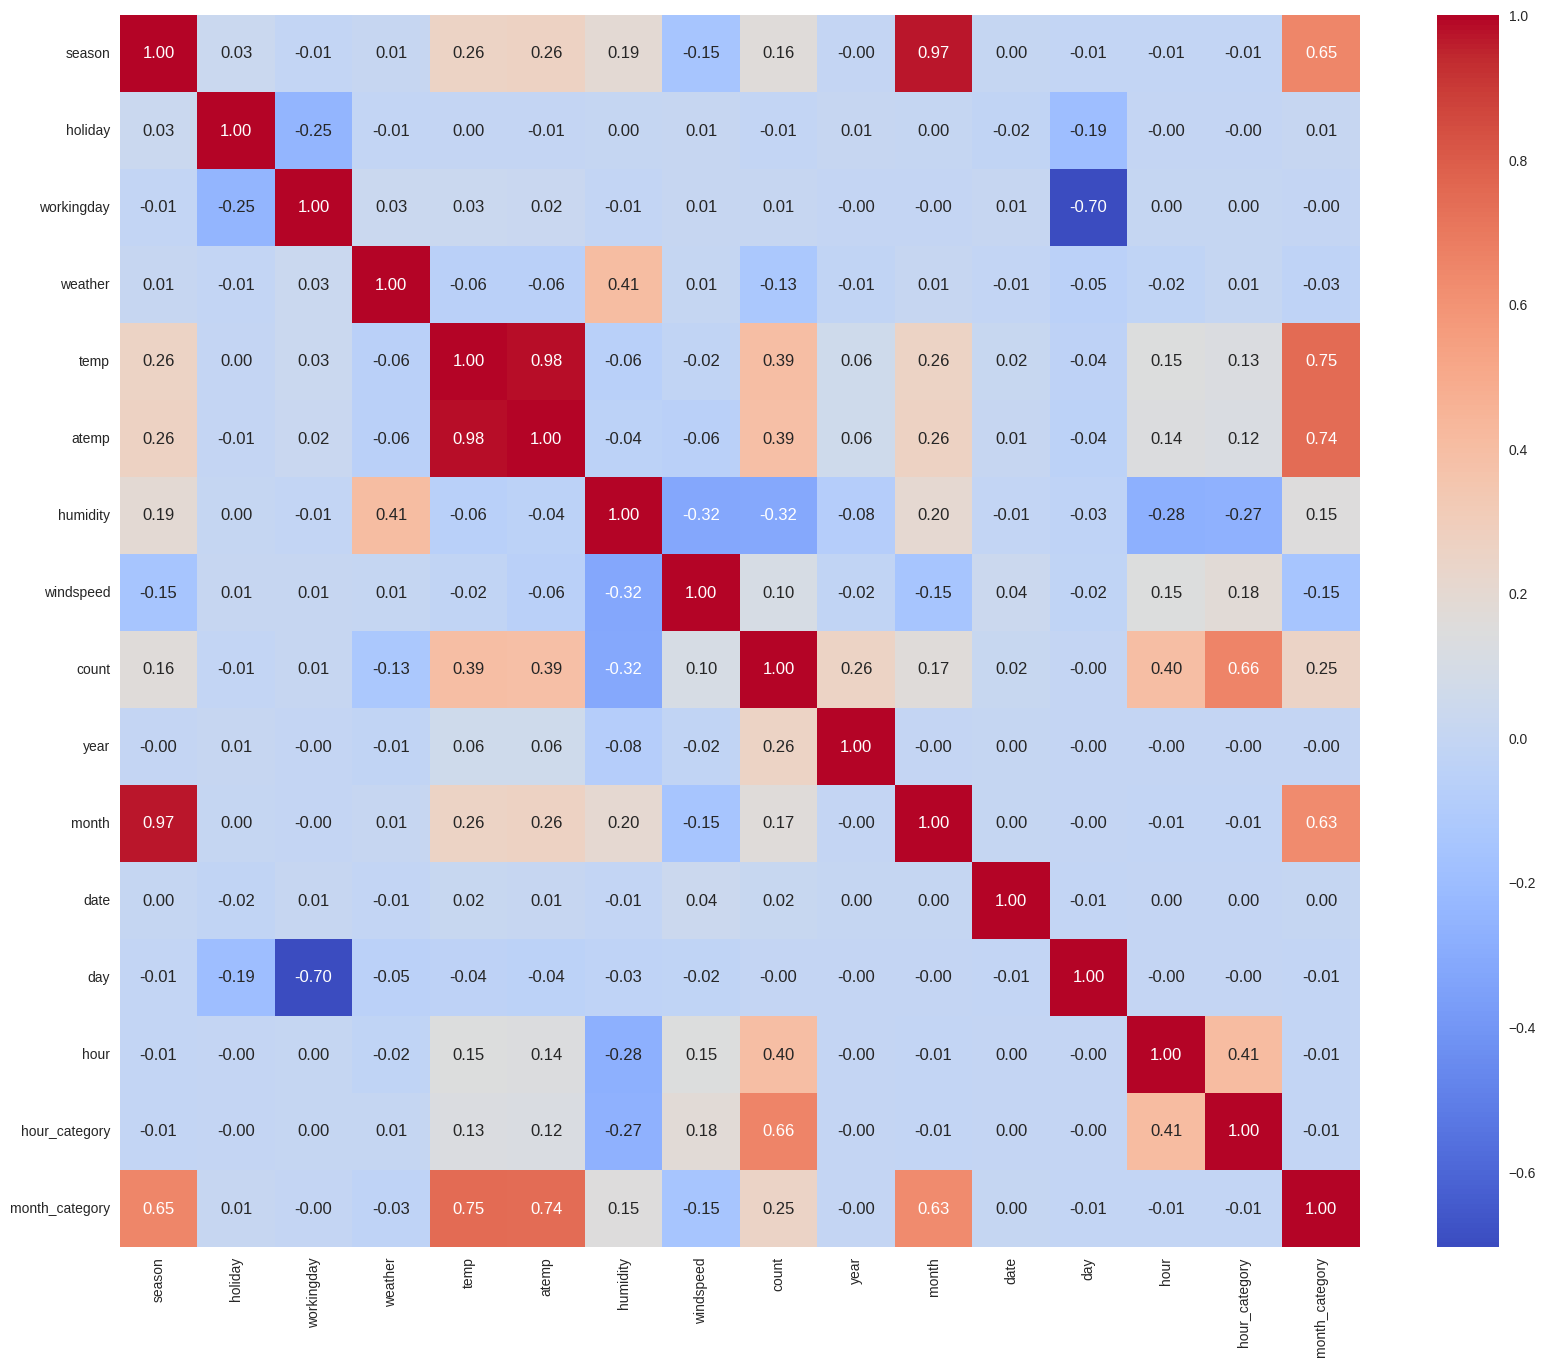

In [49]:
plt.figure(figsize=(20,16))
sns.heatmap(train_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

- This categorizing increased the correlation. So we will drop previous features.
- We will also drop features that has low correlation with count.
- atemp and temp is kind of similar so we will drop one of them.

In [50]:
train_data.drop(columns=['date', 'day', 'hour', 'month', 'holiday', 'workingday','atemp','windspeed'], inplace=True)
test_data.drop(columns=['date', 'day', 'hour', 'month', 'holiday', 'workingday','atemp','windspeed'], inplace=True)


train_data.head()

,season,weather,temp,humidity,count,year,hour_category,month_category
0,1,1,9.84,81,16,2011,0,0
1,1,1,9.02,80,40,2011,0,0
2,1,1,9.02,80,32,2011,0,0
3,1,1,9.84,75,13,2011,0,0
4,1,1,9.84,75,1,2011,0,0


## 4.Encoding

In [51]:
year_map = {
    2011 : 0,
    2012 : 1
}
train_data['year'] = train_data['year'].map(year_map)
test_data['year'] = test_data['year'].map(year_map)

- Mapped year to 0 and 1.

In [52]:
categorical_features = ['season', 'weather']

train_data = pd.get_dummies(train_data, columns=categorical_features)
test_data = pd.get_dummies(test_data, columns=categorical_features)


- Applied one-hot encoding to categorical features.

In [53]:
train_data = train_data.astype(float)
test_data = test_data.astype(float)

## 4.Transformation

In [54]:
continuous_features = ['temp', 'humidity', 'count']

train_data[continuous_features].skew()

,0
temp,0.003691
humidity,-0.086335
count,1.242066


- We will apply log1p transformation to `count` [only in train dataset]

In [55]:
train_data['count'] = np.log1p(train_data['count'])

In [56]:
train_x = train_data.drop(columns=['count'])
train_y = train_data['count']

## 5.Scaling

In [57]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on train_data and transform it
train_x = pd.DataFrame(scaler.fit_transform(train_x), index=train_x.index, columns=train_x.columns)

# Transform the test_data using the same scaler
test_x = pd.DataFrame(scaler.fit_transform(test_data), index=test_data.index, columns=test_data.columns)


- Scaled trained and test data except count column.

In [58]:
train_x.shape, test_x.shape

((10886, 13), (6493, 13))

In [59]:
train_x.head()

,temp,humidity,year,hour_category,month_category,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,-1.333661,0.993213,-1.003866,-1.126724,-1.469613,1.747245,-0.578977,-0.578977,-0.579118,0.716677,-0.593264,-0.292692,-0.009585
1,-1.438907,0.941249,-1.003866,-1.126724,-1.469613,1.747245,-0.578977,-0.578977,-0.579118,0.716677,-0.593264,-0.292692,-0.009585
2,-1.438907,0.941249,-1.003866,-1.126724,-1.469613,1.747245,-0.578977,-0.578977,-0.579118,0.716677,-0.593264,-0.292692,-0.009585
3,-1.333661,0.681430,-1.003866,-1.126724,-1.469613,1.747245,-0.578977,-0.578977,-0.579118,0.716677,-0.593264,-0.292692,-0.009585
4,-1.333661,0.681430,-1.003866,-1.126724,-1.469613,1.747245,-0.578977,-0.578977,-0.579118,0.716677,-0.593264,-0.292692,-0.009585


# Modeling

In [60]:
from pycaret.regression import *

In [61]:
train_data_with_target = pd.concat([train_x, train_y], axis=1)

In [62]:
train_data_with_target.head()

,temp,humidity,year,hour_category,month_category,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4,count
0,-1.333661,0.993213,-1.003866,-1.126724,-1.469613,1.747245,-0.578977,-0.578977,-0.579118,0.716677,-0.593264,-0.292692,-0.009585,2.833213
1,-1.438907,0.941249,-1.003866,-1.126724,-1.469613,1.747245,-0.578977,-0.578977,-0.579118,0.716677,-0.593264,-0.292692,-0.009585,3.713572
2,-1.438907,0.941249,-1.003866,-1.126724,-1.469613,1.747245,-0.578977,-0.578977,-0.579118,0.716677,-0.593264,-0.292692,-0.009585,3.496508
3,-1.333661,0.681430,-1.003866,-1.126724,-1.469613,1.747245,-0.578977,-0.578977,-0.579118,0.716677,-0.593264,-0.292692,-0.009585,2.639057
4,-1.333661,0.681430,-1.003866,-1.126724,-1.469613,1.747245,-0.578977,-0.578977,-0.579118,0.716677,-0.593264,-0.292692,-0.009585,0.693147


In [63]:
# Setup PyCaret for regression
regression_setup = setup(
    data=train_data_with_target,
    target='count',
    normalize=True,      # Scales all features
    session_id=42,
)

,Description,Value
0,Session id,42
1,Target,count
2,Target type,Regression
3,Original data shape,"(10886, 14)"
4,Transformed data shape,"(10886, 14)"
5,Transformed train set shape,"(7620, 14)"
6,Transformed test set shape,"(3266, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


- Lets see which model gives lowest error.

In [64]:
compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.5972,0.6604,0.8123,0.6722,0.2002,0.2091,0.6200
gbr,Gradient Boosting Regressor,0.6036,0.6623,0.8135,0.6712,0.2001,0.2115,0.4080
catboost,CatBoost Regressor,0.5979,0.6644,0.8148,0.6701,0.2007,0.2087,2.3610
xgboost,Extreme Gradient Boosting,0.6099,0.7003,0.8366,0.6521,0.2055,0.2101,0.2190
knn,K Neighbors Regressor,0.6227,0.7373,0.8584,0.6336,0.2092,0.2135,0.1530
ada,AdaBoost Regressor,0.6729,0.7446,0.8627,0.6301,0.2053,0.2226,0.1490
rf,Random Forest Regressor,0.6231,0.7543,0.8683,0.6249,0.2114,0.2119,1.5330
lar,Least Angle Regression,0.6826,0.7798,0.8826,0.6133,0.2126,0.2374,0.0850
br,Bayesian Ridge,0.6825,0.7798,0.8826,0.6133,0.2126,0.2375,0.0790
ridge,Ridge Regression,0.6826,0.7798,0.8826,0.6133,0.2126,0.2374,0.0970


Processing:   0%|          | 0/85 [00:00<?, ?it/s]

LGBMRegressor(n_jobs=-1, random_state=42)

- Gradient Boosting Regressor model giving lowest RMSLE.

In [65]:
from sklearn.ensemble import GradientBoostingRegressor

In [66]:
model = GradientBoostingRegressor()
model.fit(train_x, train_y)

GradientBoostingRegressor()

- Trained the model using gbr model.

In [67]:
y_pred = model.predict(test_x)
final_pred = np.expm1(y_pred)

- Applied exp to prediction since we transformed(log1p) count before.

In [68]:
final_pred

array([ 10.46487789,  10.46487789,  10.46487789, ..., 130.79158089,
        20.35751455,  17.34939983])

In [69]:
submission_data = pd.read_csv('sampleSubmission.csv')
submission_data['count'] = final_pred
submission_data.to_csv('submission_1.csv', index=False)

- Our Submission data is ready.

In [70]:
submission_data.head()

,datetime,count
0,2011-01-20 00:00:00,10.464878
1,2011-01-20 01:00:00,10.464878
2,2011-01-20 02:00:00,10.464878
3,2011-01-20 03:00:00,10.464878
4,2011-01-20 04:00:00,10.464878
